<a href="https://www.kaggle.com/code/aamir28/superstore-sales-fulfillment?scriptVersionId=344286789" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#2B2E33; padding:44px 42px; border-radius:4px; border:3px dashed #F2B705; font-family:'Arial Narrow',Arial,sans-serif;">

  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:14px;">
    <span style="background:#F2B705; color:#2B2E33; font-size:11px; font-weight:900; padding:5px 14px; letter-spacing:1.5px; font-family:Arial,sans-serif;">⚠ DISTRIBUTION CENTER DATA</span>
    <span style="font-family:'Courier New',monospace; font-size:11px; color:#8A9199;">ARCHIVE: train_csv.zip → train.csv</span>
  </div>

  <h1 style="margin:12px 0 8px 0; font-size:34px; color:#F5F6F7; font-weight:800; letter-spacing:-0.3px; font-family:Arial,sans-serif;">
    Superstore Sales &amp; Fulfillment
  </h1>
  <p style="margin:0 0 28px 0; font-size:15px; color:#B8C0C8; font-family:Arial,sans-serif; max-width:640px;">
    9,800 order line items · 4 years · 4 regions · from order placed to box shipped
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:1px; background:#42474F; font-family:Arial,sans-serif;">
    <div style="background:#34383E; padding:15px; text-align:center;">
      <div style="color:#F2B705; font-size:20px; font-weight:800;">4,922</div>
      <div style="color:#8A9199; font-size:10px; margin-top:2px;">ORDERS</div>
    </div>
    <div style="background:#34383E; padding:15px; text-align:center;">
      <div style="color:#F2B705; font-size:20px; font-weight:800;">793</div>
      <div style="color:#8A9199; font-size:10px; margin-top:2px;">CUSTOMERS</div>
    </div>
    <div style="background:#34383E; padding:15px; text-align:center;">
      <div style="color:#F2B705; font-size:20px; font-weight:800;">1,861</div>
      <div style="color:#8A9199; font-size:10px; margin-top:2px;">SKUs</div>
    </div>
    <div style="background:#34383E; padding:15px; text-align:center;">
      <div style="color:#F2B705; font-size:20px; font-weight:800;">2015–18</div>
      <div style="color:#8A9199; font-size:10px; margin-top:2px;">COVERAGE</div>
    </div>
  </div>

  <p style="margin:20px 0 0 0; font-size:12px; color:#8A9199; font-family:Arial,sans-serif;">
    Author: <b style="color:#DDE1E5;">Muhammad Aamir</b> &nbsp;|&nbsp; Target: <code>Sales</code> &nbsp;|&nbsp; Note: dates in the source file are DD/MM/YYYY, not the US MM/DD/YYYY you might expect — see Section 3
  </p>

</div>



<div style="background:#F4F5F6; border-left:4px solid #F2B705; border-radius:4px; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#2B2E33;">
<h3 style="margin-top:0; font-weight:800; color:#2B2E33; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Manifest</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#B8860B; text-decoration:none;">Setup &amp; Warehouse Styling</a></li>
<li><a href="#firstlook" style="color:#B8860B; text-decoration:none;">First Look at the Line Items</a></li>
<li><a href="#quality" style="color:#B8860B; text-decoration:none;">Data Quality: the Date Format Gotcha</a></li>
<li><a href="#shipping" style="color:#B8860B; text-decoration:none;">Order &amp; Shipping Operations</a></li>
<li><a href="#category" style="color:#B8860B; text-decoration:none;">Category &amp; Sub-Category Landscape</a></li>
<li><a href="#regional" style="color:#B8860B; text-decoration:none;">Regional &amp; Segment Performance</a></li>
<li><a href="#trend" style="color:#B8860B; text-decoration:none;">Sales Over Time</a></li>
<li><a href="#top" style="color:#B8860B; text-decoration:none;">Top Customers, States &amp; Products</a></li>
<li><a href="#corr" style="color:#B8860B; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#B8860B; text-decoration:none;">Ops Dashboard</a></li>
<li><a href="#model" style="color:#B8860B; text-decoration:none;">Predicting Sales</a></li>
<li><a href="#conclusion" style="color:#B8860B; text-decoration:none;">Closing Manifest</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">📦 1. Setup &amp; Warehouse Styling</h2>

In [1]:

import zipfile, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Distribution Center" steel & safety-yellow palette ----
BG        = '#F4F5F6'
PANEL     = '#FFFFFF'
INK       = '#2B2E33'
INK_SOFT  = '#6E7580'
YELLOW    = '#F2B705'
STEEL     = '#3E6B8C'
RED       = '#C0392B'
GREEN     = '#3E8C6E'
PURPLE    = '#7B5EA7'
GRID      = '#E2E5E8'

CATEGORY_COLORS = {'Technology': STEEL, 'Furniture': YELLOW, 'Office Supplies': GREEN}
SEGMENT_COLORS = {'Consumer': STEEL, 'Corporate': YELLOW, 'Home Office': PURPLE}
PALETTE_CAT = [STEEL, YELLOW, GREEN, RED, PURPLE]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Warehouse styling loaded.")


Warehouse styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">📋 2. First Look at the Line Items</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv')
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.head(5)



Shape: 9,800 rows x 18 columns



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

<h2 id="quality" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🗓️ 3. Data Quality: the Date Format Gotcha</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nThe single missing Postal Code belongs to: {df[df['Postal Code'].isnull()][['City','State']].drop_duplicates().values.tolist()}")
print("(a known gap in this widely-used dataset — left as-is rather than guessed at, since it doesn't affect any analysis below)")


Duplicate rows: 0

Missing values:
Postal Code    11
dtype: int64

The single missing Postal Code belongs to: [['Burlington', 'Vermont']]
(a known gap in this widely-used dataset — left as-is rather than guessed at, since it doesn't affect any analysis below)


In [5]:

# Sanity check the date format before parsing: is it MM/DD or DD/MM?
sample_dates = df['Order Date'].head(20).tolist()
print("Sample raw Order Date values:", sample_dates[:6])

# Any first-token value above 12 can only be a day, not a month — that settles the format
first_tokens = df['Order Date'].str.split('/').str[0].astype(int)
print(f"\nValues in the first date position range from {first_tokens.min()} to {first_tokens.max()} —")
print("since months only go up to 12, values above that confirm this file uses DD/MM/YYYY, not the US-typical MM/DD/YYYY.")

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
print(f"\nParsed order date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")


Sample raw Order Date values: ['08/11/2017', '08/11/2017', '12/06/2017', '11/10/2016', '11/10/2016', '09/06/2015']

Values in the first date position range from 1 to 31 —
since months only go up to 12, values above that confirm this file uses DD/MM/YYYY, not the US-typical MM/DD/YYYY.

Parsed order date range: 2015-01-03 to 2018-12-30


<h2 id="shipping" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🚚 4. Order &amp; Shipping Operations</h2>

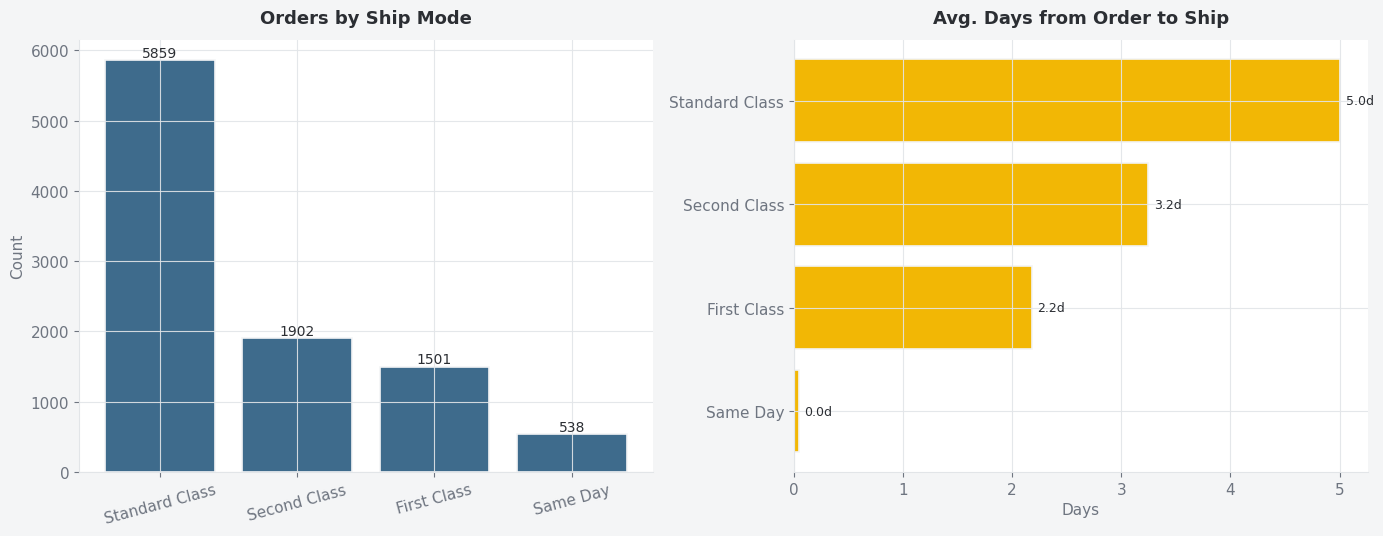

Ship times line up exactly with what each mode promises — Same Day ships same-day, Standard Class
takes roughly 5 days — a good internal-consistency check on the shipping data.


In [6]:

df['ship_days'] = (df['Ship Date'] - df['Order Date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
mode_counts = df['Ship Mode'].value_counts()
bars = ax.bar(mode_counts.index, mode_counts.values, color=STEEL, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Orders by Ship Mode', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=15)

ax = axes[1]
ship_time = df.groupby('Ship Mode')['ship_days'].mean().sort_values()
bars = ax.barh(ship_time.index, ship_time.values, color=YELLOW, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.05, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}d", va='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Days from Order to Ship', 'Days', '')

plt.tight_layout()
plt.show()

print("Ship times line up exactly with what each mode promises — Same Day ships same-day, Standard Class")
print("takes roughly 5 days — a good internal-consistency check on the shipping data.")


<h2 id="category" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🏷️ 5. Category &amp; Sub-Category Landscape</h2>

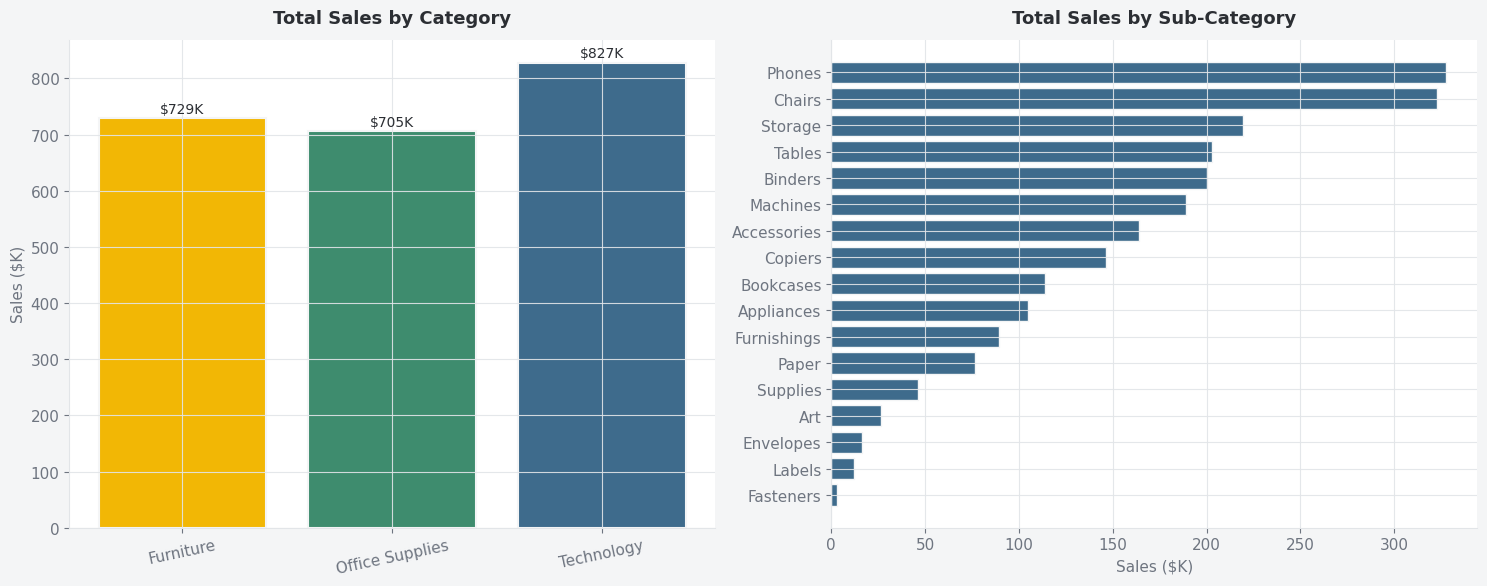

Technology has the highest average sale ($456) despite the fewest line items —
Office Supplies has the most line items but the lowest average sale ($119),
a classic 'many small orders vs. few big-ticket ones' contrast between categories.


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
cat_sales = df.groupby('Category')['Sales'].agg(['sum','mean'])
bars = ax.bar(cat_sales.index, cat_sales['sum']/1000, color=[CATEGORY_COLORS[c] for c in cat_sales.index], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10, f"${b.get_height():.0f}K", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Total Sales by Category', '', 'Sales ($K)')
plt.setp(ax.get_xticklabels(), rotation=12)

ax = axes[1]
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()
bars = ax.barh(subcat_sales.index, subcat_sales.values/1000, color=STEEL, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Total Sales by Sub-Category', 'Sales ($K)', '')

plt.tight_layout()
plt.show()

print(f"Technology has the highest average sale (${cat_sales.loc['Technology','mean']:.0f}) despite the fewest line items —")
print(f"Office Supplies has the most line items but the lowest average sale (${cat_sales.loc['Office Supplies','mean']:.0f}),")
print("a classic 'many small orders vs. few big-ticket ones' contrast between categories.")


<h2 id="regional" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🗺️ 6. Regional &amp; Segment Performance</h2>

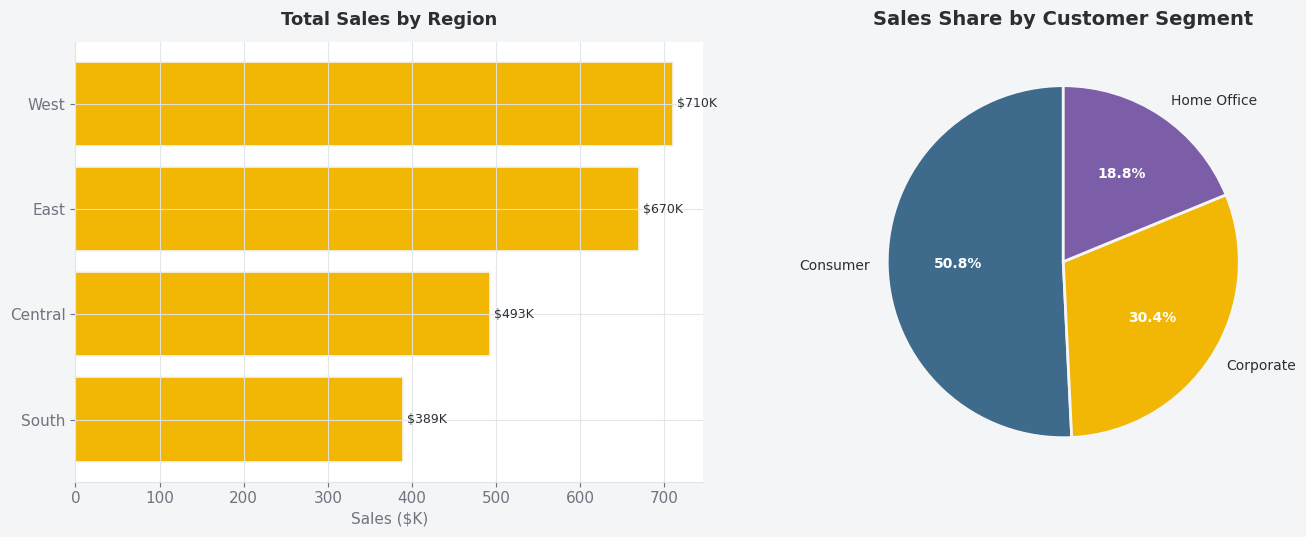

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
bars = ax.barh(region_sales.index, region_sales.values/1000, color=YELLOW, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+5, b.get_y()+b.get_height()/2, f"${b.get_width():.0f}K", va='center', fontsize=9, color=INK)
style_ax(ax, 'Total Sales by Region', 'Sales ($K)', '')

ax = axes[1]
segment_sales = df.groupby('Segment')['Sales'].sum()
wedges, texts, autotexts = ax.pie(segment_sales.values, labels=segment_sales.index,
       colors=[SEGMENT_COLORS[s] for s in segment_sales.index], autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':BG,'linewidth':2}, textprops={'fontsize':10})
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Sales Share by Customer Segment', color=INK, pad=12)

plt.tight_layout()
plt.show()


<h2 id="trend" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">📈 7. Sales Over Time</h2>

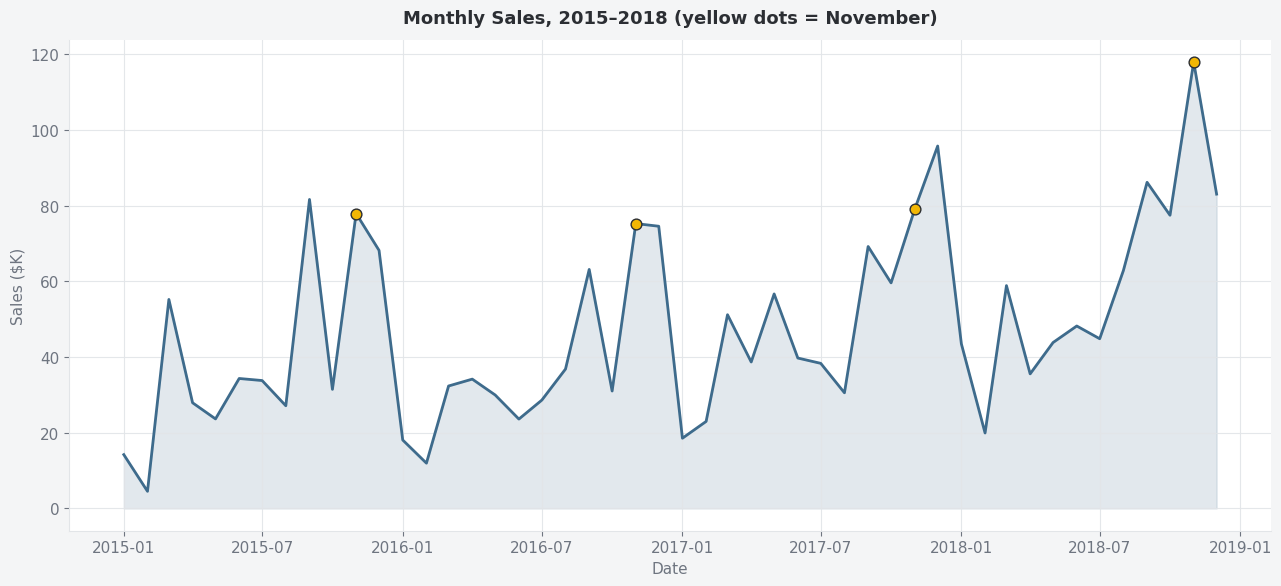

November consistently spikes above the surrounding months every year — average November sales run
roughly 2.0x a typical other month, matching the well-known Black Friday/holiday
shopping surge that shows up in most US retail sales data.


In [9]:

monthly = df.set_index('Order Date')['Sales'].resample('MS').sum()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(monthly.index, monthly.values/1000, color=STEEL, linewidth=2)
ax.fill_between(monthly.index, monthly.values/1000, color=STEEL, alpha=0.15)
for year in range(2015, 2019):
    nov = pd.Timestamp(f'{year}-11-01')
    if nov in monthly.index:
        ax.scatter([nov], [monthly[nov]/1000], color=YELLOW, s=60, zorder=5, edgecolor=INK, linewidth=1)
style_ax(ax, 'Monthly Sales, 2015–2018 (yellow dots = November)', 'Date', 'Sales ($K)')
plt.tight_layout()
plt.show()

nov_avg = df[df['Order Date'].dt.month==11]['Sales'].sum() / df['Order Date'].dt.year.nunique()
other_avg = df[df['Order Date'].dt.month!=11]['Sales'].sum() / (df['Order Date'].dt.year.nunique() * 11)
print(f"November consistently spikes above the surrounding months every year — average November sales run")
print(f"roughly {nov_avg/other_avg:.1f}x a typical other month, matching the well-known Black Friday/holiday")
print("shopping surge that shows up in most US retail sales data.")


<h2 id="top" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🏆 8. Top Customers, States &amp; Products</h2>

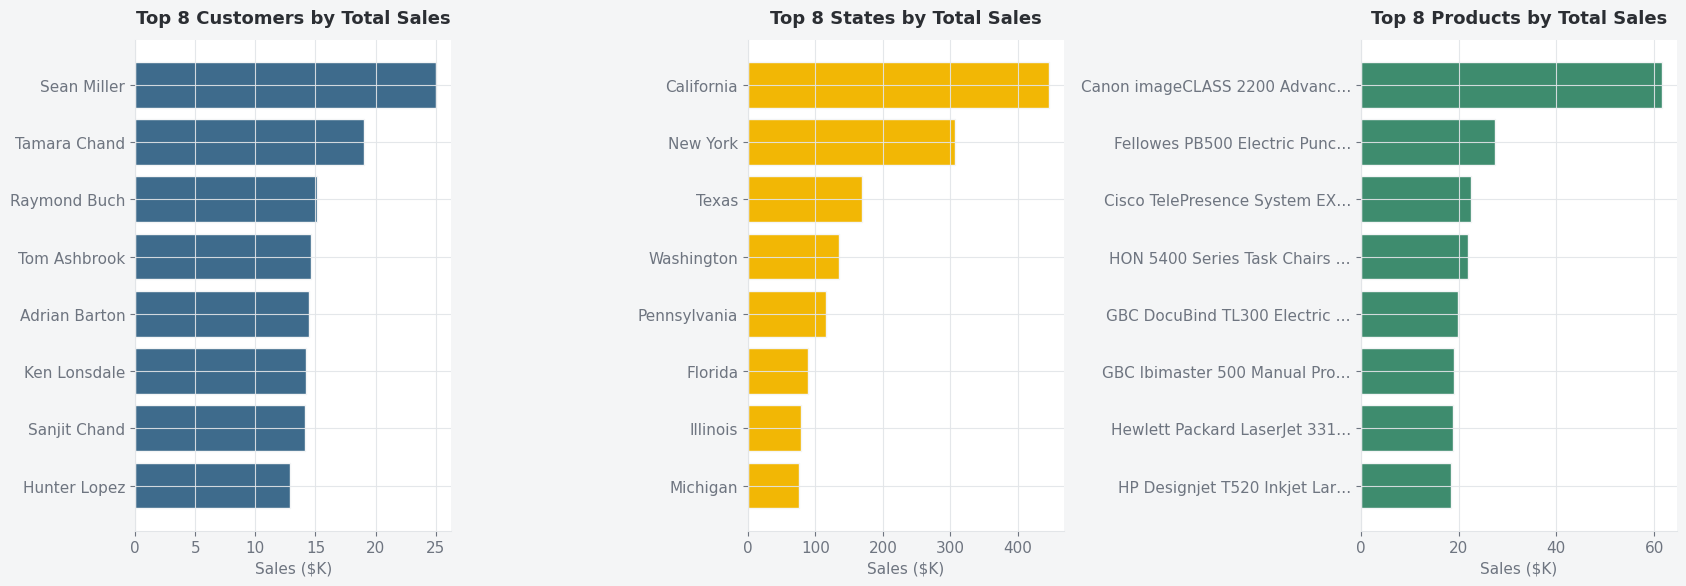

California and New York alone account for 33%
of total sales — consistent with population and business-density patterns in the real US market.


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

ax = axes[0]
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(8)
bars = ax.barh(top_customers.index[::-1], top_customers.values[::-1]/1000, color=STEEL, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 8 Customers by Total Sales', 'Sales ($K)', '')

ax = axes[1]
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(8)
bars = ax.barh(top_states.index[::-1], top_states.values[::-1]/1000, color=YELLOW, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 8 States by Total Sales', 'Sales ($K)', '')

ax = axes[2]
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(8)
bars = ax.barh([p[:28]+'…' if len(p)>28 else p for p in top_products.index[::-1]], top_products.values[::-1]/1000, color=GREEN, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 8 Products by Total Sales', 'Sales ($K)', '')

plt.tight_layout()
plt.show()

print(f"California and New York alone account for {(top_states.iloc[0]+top_states.iloc[1])/df.Sales.sum()*100:.0f}%")
print("of total sales — consistent with population and business-density patterns in the real US market.")


<h2 id="corr" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🔗 9. Correlation Check</h2>

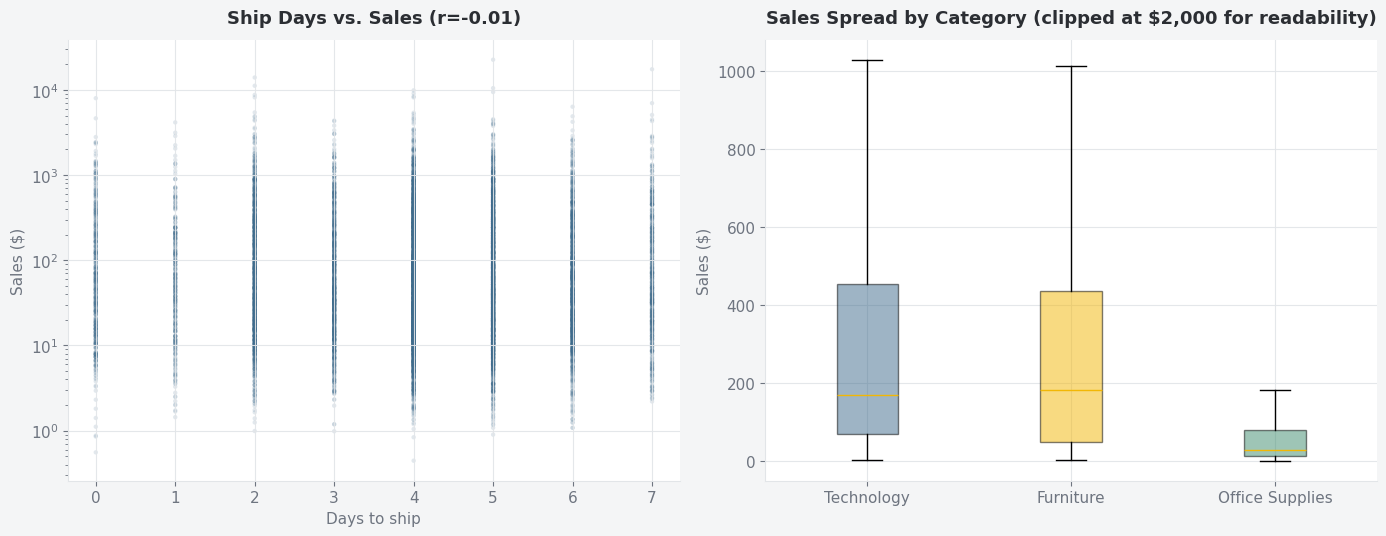

Ship speed and sale amount are essentially unrelated (r=-0.01) — how fast something ships doesn't
track with how expensive it is, which makes sense since shipping speed is a customer choice, not a
product characteristic.


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.scatter(df['ship_days'], df['Sales'], alpha=0.15, s=10, color=STEEL, edgecolor='none')
r = df['ship_days'].corr(df['Sales'])
style_ax(ax, f'Ship Days vs. Sales (r={r:.2f})', 'Days to ship', 'Sales ($)')
ax.set_yscale('log')

ax = axes[1]
cat_box_data = [df[df.Category==c]['Sales'].clip(upper=2000) for c in CATEGORY_COLORS]
bp = ax.boxplot(cat_box_data, labels=list(CATEGORY_COLORS.keys()), patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], CATEGORY_COLORS.values()):
    patch.set_facecolor(c); patch.set_alpha(0.5)
style_ax(ax, 'Sales Spread by Category (clipped at $2,000 for readability)', '', 'Sales ($)')

plt.tight_layout()
plt.show()

print(f"Ship speed and sale amount are essentially unrelated (r={r:.2f}) — how fast something ships doesn't")
print("track with how expensive it is, which makes sense since shipping speed is a customer choice, not a")
print("product characteristic.")


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">📊 10. Ops Dashboard</h2>

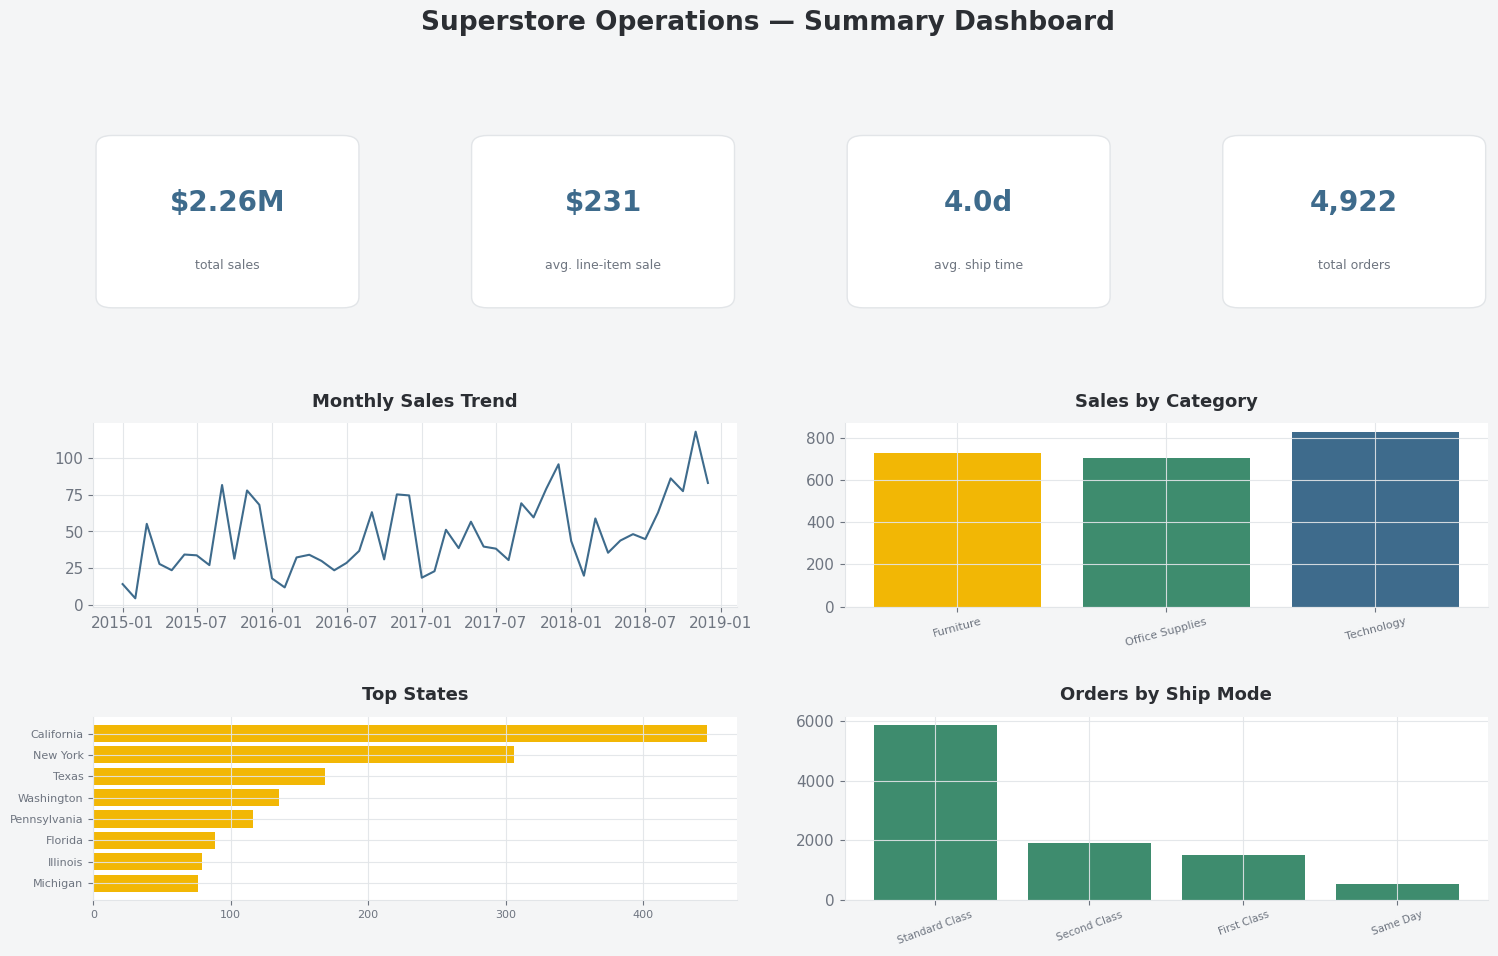

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Superstore Operations — Summary Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"${df['Sales'].sum()/1e6:.2f}M", "total sales"),
    (f"${df['Sales'].mean():.0f}", "avg. line-item sale"),
    (f"{df['ship_days'].mean():.1f}d", "avg. ship time"),
    (f"{df['Order ID'].nunique():,}", "total orders"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=20, color=STEEL, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
ax.plot(monthly.index, monthly.values/1000, color=STEEL, linewidth=1.5)
style_ax(ax, 'Monthly Sales Trend', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.bar(cat_sales.index, cat_sales['sum']/1000, color=[CATEGORY_COLORS[c] for c in cat_sales.index])
style_ax(ax, 'Sales by Category', '', '')
plt.setp(ax.get_xticklabels(), rotation=15, fontsize=8)

ax = fig.add_subplot(gs[2, :2])
bars = ax.barh(top_states.index[::-1], top_states.values[::-1]/1000, color=YELLOW)
style_ax(ax, 'Top States', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(mode_counts.index, mode_counts.values, color=GREEN)
style_ax(ax, 'Orders by Ship Mode', '', '')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=7.5)

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#F5F6F7; background:#2B2E33; padding:12px 18px; border-radius:4px;">🤖 11. Predicting Sales</h2>
<p style="color:#4A4A4A; font-family:Arial,Helvetica,sans-serif; background:#F4F5F6; padding:8px 18px; border-radius:4px;">We predict <code>Sales</code> (log-transformed, given its heavily right-skewed distribution) from order/product/customer metadata — deliberately excluding <code>Product Name</code> and <code>Product ID</code> themselves, since near-perfectly memorizing 1,861 individual product prices isn't a generalizable modeling exercise.</p>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.copy()
model_df['order_month'] = model_df['Order Date'].dt.month
cat_cols = ['Ship Mode', 'Segment', 'Region', 'State', 'Category', 'Sub-Category']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['Ship Mode', 'Segment', 'Region', 'State', 'Category', 'Sub-Category', 'ship_days', 'order_month']
X = model_df[features]
y = np.log1p(model_df['Sales'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² (log-sales) = {r2:.3f} | MAE (log-sales) = {mae:.3f}")


Random Forest: R² (log-sales) = 0.447 | MAE (log-sales) = 0.951
XGBoost: R² (log-sales) = 0.417 | MAE (log-sales) = 0.979


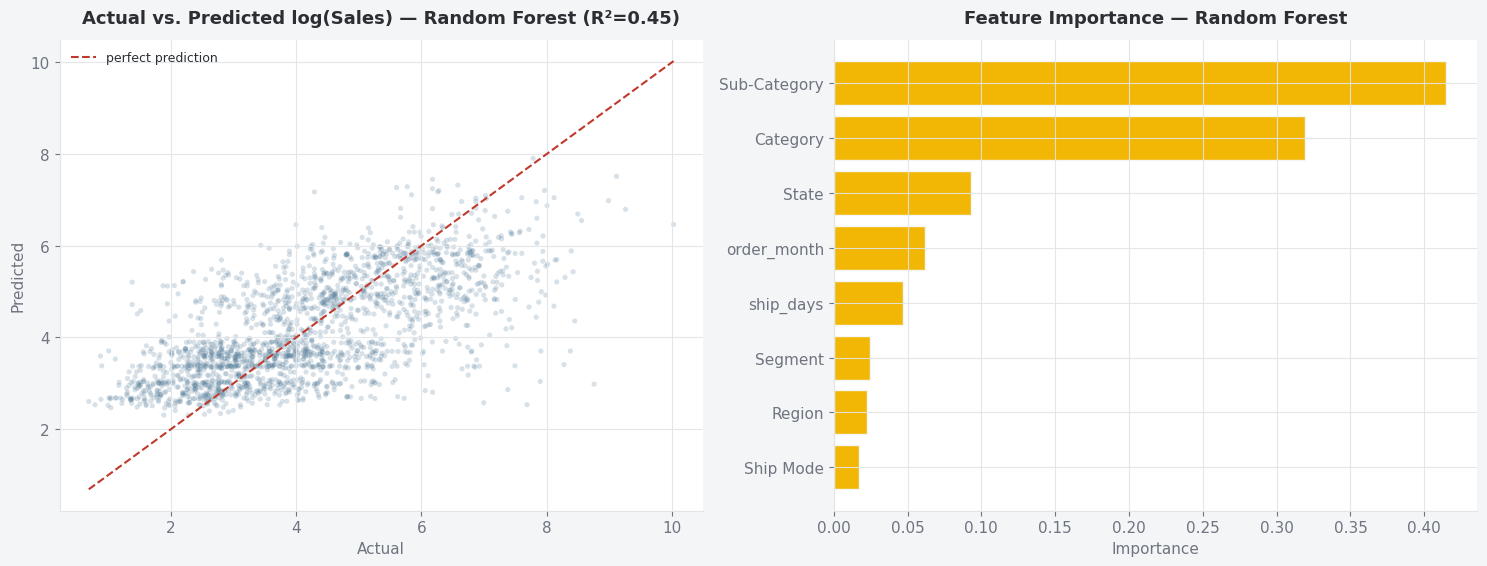

In [14]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test, best['pred'], alpha=0.2, s=14, color=STEEL, edgecolor='none')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color=RED, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted log(Sales) — {best_name} (R²={best["r2"]:.2f})', 'Actual', 'Predicted')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
importances = pd.Series(best['model'].feature_importances_, index=features).sort_values()
ax.barh(importances.index, importances.values, color=YELLOW, edgecolor=BG)
style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F4F5F6; border-left:3px solid #F2B705; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:4px;">
Sub-Category and Category dominate feature importance — different product types genuinely cluster at different
price points (a chair costs more than a binder, regardless of region or season). The R² lands in a moderate,
believable range rather than near-perfect: without the specific product itself in the feature set, this metadata
alone can only explain part of what any individual line item sells for — exactly what we'd expect for real retail
transaction data.
</div>



<div style="background:#2B2E33; padding:38px 42px; border-radius:4px; border:3px dashed #F2B705; font-family:Arial,Helvetica,sans-serif; color:#DDE1E5;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#F2B705; border-bottom:1px solid #42474F; padding-bottom:10px;">📦 12. Closing Manifest</h2>

<h4 style="color:#F2B705; font-weight:700; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#C4CBD3;">
<li>Ship times line up exactly with what each shipping mode promises — Same Day ships same-day, Standard Class takes roughly 5 days — good internal consistency.</li>
<li>Technology has the highest average sale but fewest line items; Office Supplies has the most line items but the lowest average sale — a believable "few big-ticket vs. many small" contrast.</li>
<li>November sales spike consistently across all four years, matching the well-known Black Friday/holiday shopping surge in US retail data.</li>
<li>California and New York dominate state-level sales, tracking real population and business density.</li>
<li>Ship speed and sale amount are essentially uncorrelated — a sensible finding, since shipping speed is a customer's choice at checkout, not a property of the product itself.</li>
</ul>

<h4 style="color:#F2B705; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<p style="font-size:14.5px; color:#C4CBD3; line-height:1.8;">
This file's dates are DD/MM/YYYY, not the US-typical MM/DD/YYYY you might assume from "United States" being the
only country in the data — verified directly from the date values themselves (several first-position values
exceed 12) before parsing, rather than assumed.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8A9199; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
